In [1]:
# Control-composition sensitivity review (Moore et al. Batch_1)
# Reads only what run_control_composition*.py already wrote to Analysis_Results/Control_Composition/
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from viz_style import apply_style
apply_style()
import config

res = pd.read_csv(config.CTRL_COMP_DIR / 'jaccard_results.csv')
null = pd.read_csv(config.CTRL_COMP_DIR / 'null_distribution.csv')
print(f"tertile rows: {len(res)}, null rows: {len(null)}")
res.head()

tertile rows: 198, null rows: 3600


,jaccard_k25,signflip_k25,jaccard_k50,signflip_k50,jaccard_k100,signflip_k100,jaccard_k200,signflip_k200,jaccard_k500,signflip_k500,spearman,disease,split,axis,draw,tag,layer,n_case,n_ctrl,delta_d
0,0.000000,NaN,0.003367,0.0,0.011810,0.0,0.016994,0.0,0.038521,0.0,0.305712,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,CPM_log1p,72,23.0,2.358629
1,0.000000,NaN,0.006803,0.0,0.016990,0.0,0.023964,0.0,0.043509,0.0,0.304923,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TPM_log2,72,23.0,2.358629
2,0.000000,NaN,0.000000,NaN,0.006734,0.0,0.012714,0.0,0.035703,0.0,0.312630,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TMM_log2,72,23.0,2.358629
3,0.006803,0.0,0.010309,0.0,0.013765,0.0,0.026848,0.0,0.050207,0.0,0.351389,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k1,72,23.0,2.358629
4,0.000000,NaN,0.000000,NaN,0.015281,0.0,0.023103,0.0,0.046259,0.0,0.367063,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k2,72,23.0,2.358629


In [2]:
# 1. null p-value per (disease, layer, axis): how often a size-matched random split
# agrees no better than the bias-stratified split
def null_pvalue(res, null, metric='jaccard_k100'):
    out = []
    for (dis, lay), g in null.groupby(['disease', 'layer']):
        ref = g[metric].values
        for _, r in res[(res.disease == dis) & (res.layer == lay)].iterrows():
            out.append(dict(disease=dis, layer=lay, axis=r['axis'], obs=r[metric],
                            null_mean=float(ref.mean()), null_sd=float(ref.std()),
                            p_lower=float((ref <= r[metric]).mean())))
    return pd.DataFrame(out)

pval = null_pvalue(res, null)
pval.sort_values('p_lower').head(20)

,disease,layer,axis,obs,null_mean,null_sd,p_lower
10,Pancreatic Cancer,CPM_log1p,PC1_bias,0.005025,0.023329,0.005815,0.0
54,Pancreatic Cancer,RUVg_Platelet_k1,PC1_bias,0.005042,0.020579,0.005450,0.0
99,Pancreatitis,CPM_log1p,log(Total Reads),0.005042,0.016057,0.005157,0.0
100,Pancreatitis,CPM_log1p,Spliced Reads (%),0.005042,0.016057,0.005157,0.0
87,Pancreatic Cancer,TMM_log2,PC1_bias,0.003350,0.020098,0.005317,0.0
109,Pancreatitis,CPM_log1p,PC1_bias,0.001675,0.016057,0.005157,0.0
105,Pancreatitis,CPM_log1p,GC Bias,0.005042,0.016057,0.005157,0.0
110,Pancreatitis,Proposed_Full_k1,log(Total Reads),0.000000,0.012523,0.004666,0.0
96,Pancreatic Cancer,TPM_log2,NG80,0.008547,0.025642,0.006303,0.0
98,Pancreatic Cancer,TPM_log2,PC1_bias,0.003350,0.025642,0.006303,0.0


In [18]:
print(f"null baseline jaccard@100: mean={null['jaccard_k100'].mean():.3f}, "
     f"sd={null['jaccard_k100'].std():.3f}  (tier 1 floor, axis-independent)")
print(f"tertile vs null: median p_lower={pval['p_lower'].median():.3f}, "
     f"{(pval['p_lower'] < 0.05).mean()*100:.0f}% of (disease,layer,axis) significantly BELOW null, "
     f"{(pval['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null")

by_axis = pval.groupby('axis')['p_lower'].agg(
    median_p_lower='median',
    frac_sig_worse=lambda s: (s < 0.05).mean(),
    frac_sig_better=lambda s: (s > 0.95).mean())
by_axis.sort_values('median_p_lower')

null baseline jaccard@100: mean=0.018, sd=0.007  (tier 1 floor, axis-independent)
tertile vs null: median p_lower=0.075, 43% of (disease,layer,axis) significantly BELOW null, 2% significantly ABOVE null


,median_p_lower,frac_sig_worse,frac_sig_better
axis,,,
PC1_bias,0.0025,0.777778,0.000000
NG80,0.0150,0.666667,0.000000
log(Total Reads),0.0175,0.722222,0.000000
Gene Length Bias,0.0550,0.500000,0.000000
GC Bias,0.0550,0.444444,0.000000
gDNA Contamination (Intron/Exon),0.0650,0.444444,0.000000
RNA Degradation (3' Bias),0.1000,0.277778,0.000000
Spliced Reads (%),0.1050,0.388889,0.000000
Platelet Score,0.1175,0.388889,0.222222


In [19]:
# 3. optional deep dive into one comparison's t-statistics / expression matrices
# (written per-comparison by run_control_composition.py; load only what's needed)
tag = 'Pancreatic_Cancer__PC1_bias'
stat_dir = config.CTRL_COMP_STAT_DIR / tag
t0 = pd.read_csv(stat_dir / 'T0_welch_t.csv.gz', index_col=0)
t2 = pd.read_csv(stat_dir / 'T2_welch_t.csv.gz', index_col=0)
t0[['CPM_log1p', 'GeneName']].join(t2[['CPM_log1p']], rsuffix='_T2').sort_values('CPM_log1p').head(10)

,CPM_log1p,GeneName,CPM_log1p_T2
ENSG00000107223.14,-3.507659,EDF1,0.407309
ENSG00000124228.16,-3.502703,DDX27,1.032138
ENSG00000114861.25,-3.281962,FOXP1,-2.319043
ENSG00000242028.9,-3.106850,HYPK,0.329804
ENSG00000136802.13,-3.087232,LRRC8A,-2.334358
ENSG00000213741.12,-3.076732,RPS29,0.170255
ENSG00000116251.12,-3.042118,RPL22,0.670042
ENSG00000133106.16,-3.015448,EPSTI1,1.189197
ENSG00000100941.10,-2.949856,PNN,1.648041
ENSG00000142541.19,-2.931174,RPL13A,-0.202351


In [20]:
# 4. DESeq2 arm (run_control_composition_deseq2.py): same tags/subsets, Wald `stat` instead
# of Welch t. 2 designs only (no_covariate, ruvg_k2) and a smaller null (n=30 vs 200) --
# see script docstring for the runtime tradeoff.
d_res = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_jaccard_results.csv')
d_null = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_null_distribution.csv')
d_pval = null_pvalue(d_res, d_null)
print(f"tertile rows: {len(d_res)}, null rows: {len(d_null)}")
d_pval.sort_values('p_lower').head(20)

tertile rows: 44, null rows: 120


,disease,layer,axis,obs,null_mean,null_sd,p_lower
1,Pancreatic Cancer,no_covariate,Spliced Reads (%),0.058364,0.086005,0.010683,0.000000
7,Pancreatic Cancer,no_covariate,Gene Length Bias,0.039718,0.086005,0.010683,0.000000
5,Pancreatic Cancer,no_covariate,Platelet Score,0.036317,0.086005,0.010683,0.000000
4,Pancreatic Cancer,no_covariate,RNA Degradation (3' Bias),0.051026,0.086005,0.010683,0.000000
10,Pancreatic Cancer,no_covariate,PC1_bias,0.053537,0.086005,0.010683,0.000000
13,Pancreatic Cancer,ruvg_k2,gDNA Contamination (Intron/Exon),0.119115,0.148169,0.013428,0.000000
8,Pancreatic Cancer,no_covariate,NG80,0.056944,0.086005,0.010683,0.000000
16,Pancreatic Cancer,ruvg_k2,Platelet Score,0.114041,0.148169,0.013428,0.000000
21,Pancreatic Cancer,ruvg_k2,PC1_bias,0.104793,0.148169,0.013428,0.000000
23,Pancreatitis,no_covariate,Spliced Reads (%),0.011845,0.031693,0.008413,0.000000


25320 rows (422 tags x 5 layers x 9 K)


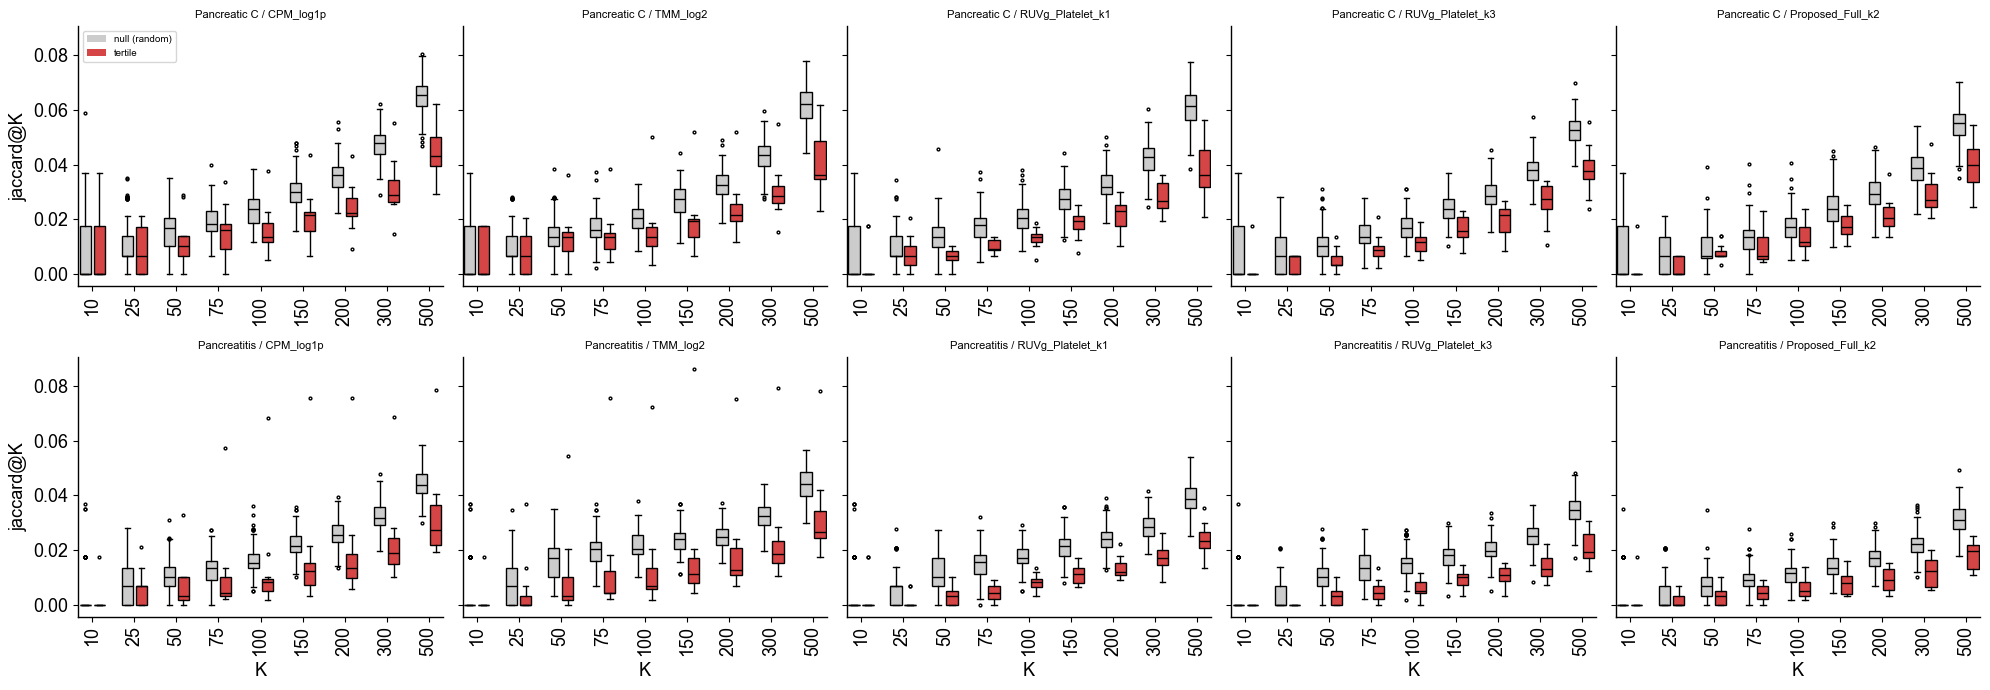

In [64]:
EXT_K_GRID = [10, 25, 50, 75, 100, 150, 200, 300, 500]
EXT_CACHE = config.CTRL_COMP_DIR / 'jaccard_extended_k.pkl'
layers_show = ['CPM_log1p', 'TMM_log2', 'RUVg_Platelet_k1', 'RUVg_Platelet_k3', 'Proposed_Full_k2']

def jaccard_at_k(ti, tj, k):
    a = set(np.argsort(-np.abs(ti))[:k])
    b = set(np.argsort(-np.abs(tj))[:k])
    return len(a & b) / len(a | b)

def tag_jaccard(tag, layers, k_grid):
    dfs = [pd.read_csv(config.CTRL_COMP_STAT_DIR / tag / f'T{t}_welch_t.csv.gz', index_col=0)[layers]
          for t in range(3)]
    rows = []
    for i in range(3):
        for j in range(i + 1, 3):
            for l in layers:
                ti, tj = dfs[i][l].values, dfs[j][l].values
                for k in k_grid:
                    rows.append(dict(layer=l, k=k, jaccard=jaccard_at_k(ti, tj, k)))
    return pd.DataFrame(rows).groupby(['layer', 'k'])['jaccard'].mean().reset_index()

if EXT_CACHE.exists():
    ext = pd.read_pickle(EXT_CACHE)
else:
    rows = []
    tags = pd.concat([res[['disease', 'split', 'tag']], null[['disease', 'split', 'tag']]]).drop_duplicates('tag')
    for _, row in tags.iterrows():
        g = tag_jaccard(row['tag'], layers_show, EXT_K_GRID)
        g['disease'], g['split'], g['tag'] = row['disease'], row['split'], row['tag']
        rows.append(g)
    ext = pd.concat(rows, ignore_index=True)
    ext.to_pickle(EXT_CACHE)
print(f"{len(ext)} rows ({ext['tag'].nunique()} tags x {len(layers_show)} layers x {len(EXT_K_GRID)} K)")

def plot_jaccard_k_box(ext, disease, layer, ax, k_grid=EXT_K_GRID):
    null_med, tert_med = [], []
    sub = ext[(ext.disease == disease) & (ext.layer == layer)]
    for i, k in enumerate(k_grid):
        nv = sub[(sub.split == 'random') & (sub.k == k)]['jaccard'].values
        rv = sub[(sub.split == 'tertile') & (sub.k == k)]['jaccard'].values
        ax.boxplot([nv], positions=[i * 3], widths=0.8, patch_artist=True,
                  boxprops=dict(facecolor='#cccccc'), medianprops=dict(color='black'), flierprops=dict(markersize=2))
        ax.boxplot([rv], positions=[i * 3 + 1], widths=0.8, patch_artist=True,
                  boxprops=dict(facecolor='#d64545'), medianprops=dict(color='black'), flierprops=dict(markersize=2))
        null_med.append(np.median(nv)); tert_med.append(np.median(rv))
    # x_null = [i * 3 for i in range(len(k_grid))]
    # x_tert = [i * 3 + 1 for i in range(len(k_grid))]
    # ax.plot(x_null, null_med, '-', color='#888888', lw=1.2, zorder=0)
    # ax.plot(x_tert, tert_med, '-', color='#d64545', lw=1.2, zorder=0)
    ax.set_xticks([i * 3 + 0.5 for i in range(len(k_grid))])
    ax.set_xticklabels(k_grid, rotation=90)

fig, axes = plt.subplots(2, len(layers_show), figsize=(4 * len(layers_show), 7), sharey=True)
for row, disease in enumerate(ext['disease'].unique()):
    for col, layer in enumerate(layers_show):
        plot_jaccard_k_box(ext, disease, layer, axes[row, col])
        axes[row, col].set_title(f'{disease[:12]} / {layer}', fontsize=8)
        if row == 1: axes[row, col].set_xlabel('K')
axes[0, 0].set_ylabel('jaccard@K')
axes[1, 0].set_ylabel('jaccard@K')

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in ['#cccccc', '#d64545']]
axes[0, 0].legend(handles, ['null (random)', 'tertile'], fontsize=7, loc='upper left')

plt.tight_layout()
config.CTRL_COMP_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.CTRL_COMP_FIG_DIR / 'jaccard_k_boxplot.png', dpi=150)
plt.show()

1968 rows (82 tags x 2 designs x 9 K)


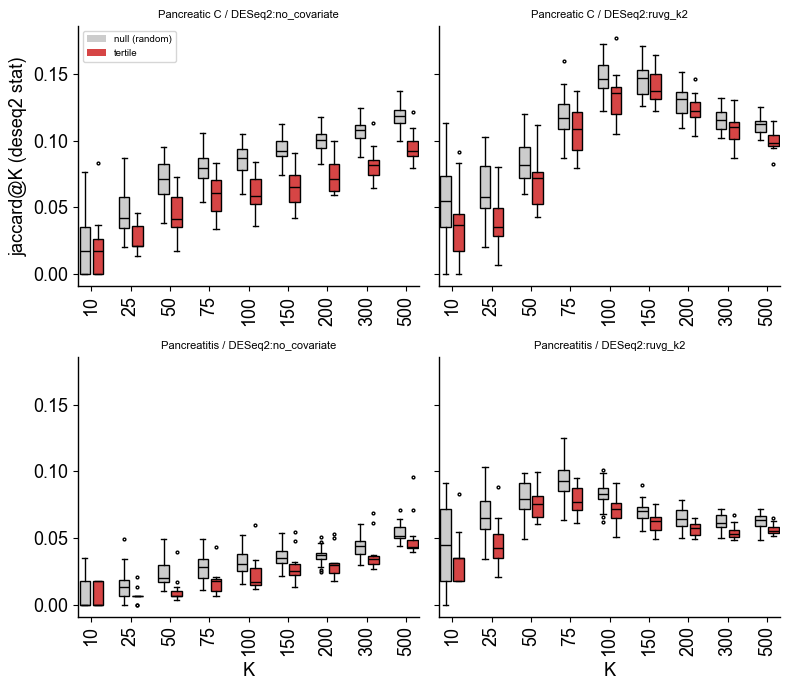

In [29]:
# 6. same boxplot+trend, DESeq2 arm. Files are one column ('stat') per (tag, stratum,
# design) rather than all layers in one file, so the reader differs; jaccard_at_k /
# plot_jaccard_k_box from cell 5 are reused as-is.
DESEQ2_DESIGNS = ['no_covariate', 'ruvg_k2']
D_EXT_CACHE = config.CTRL_COMP_DIR / 'deseq2_jaccard_extended_k.pkl'

def tag_jaccard_deseq2(tag, designs, k_grid):
    rows = []
    for i in range(3):
        for j in range(i + 1, 3):
            for d in designs:
                ti = pd.read_csv(config.CTRL_COMP_DESEQ2_DIR / tag / f'T{i}_{d}.csv.gz', index_col=0)['stat'].values
                tj = pd.read_csv(config.CTRL_COMP_DESEQ2_DIR / tag / f'T{j}_{d}.csv.gz', index_col=0)['stat'].values
                for k in k_grid:
                    rows.append(dict(layer=d, k=k, jaccard=jaccard_at_k(ti, tj, k)))
    return pd.DataFrame(rows).groupby(['layer', 'k'])['jaccard'].mean().reset_index()

if D_EXT_CACHE.exists():
    d_ext = pd.read_pickle(D_EXT_CACHE)
else:
    rows = []
    tags = pd.concat([d_res[['disease', 'split', 'tag']], d_null[['disease', 'split', 'tag']]]).drop_duplicates('tag')
    for _, row in tags.iterrows():
        g = tag_jaccard_deseq2(row['tag'], DESEQ2_DESIGNS, EXT_K_GRID)
        g['disease'], g['split'], g['tag'] = row['disease'], row['split'], row['tag']
        rows.append(g)
    d_ext = pd.concat(rows, ignore_index=True)
    d_ext.to_pickle(D_EXT_CACHE)
print(f"{len(d_ext)} rows ({d_ext['tag'].nunique()} tags x {len(DESEQ2_DESIGNS)} designs x {len(EXT_K_GRID)} K)")

fig, axes = plt.subplots(2, len(DESEQ2_DESIGNS), figsize=(4 * len(DESEQ2_DESIGNS), 7), sharey=True)
for row, disease in enumerate(d_ext['disease'].unique()):
    for col, design in enumerate(DESEQ2_DESIGNS):
        plot_jaccard_k_box(d_ext, disease, design, axes[row, col])
        axes[row, col].set_title(f'{disease[:12]} / DESeq2:{design}', fontsize=8)
        if row == 1: axes[row, col].set_xlabel('K')
axes[0, 0].set_ylabel('jaccard@K (deseq2 stat)')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in ['#cccccc', '#d64545']]
axes[0, 0].legend(handles, ['null (random)', 'tertile'], fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(config.CTRL_COMP_FIG_DIR / 'deseq2_jaccard_k_boxplot.png', dpi=150)
plt.show()

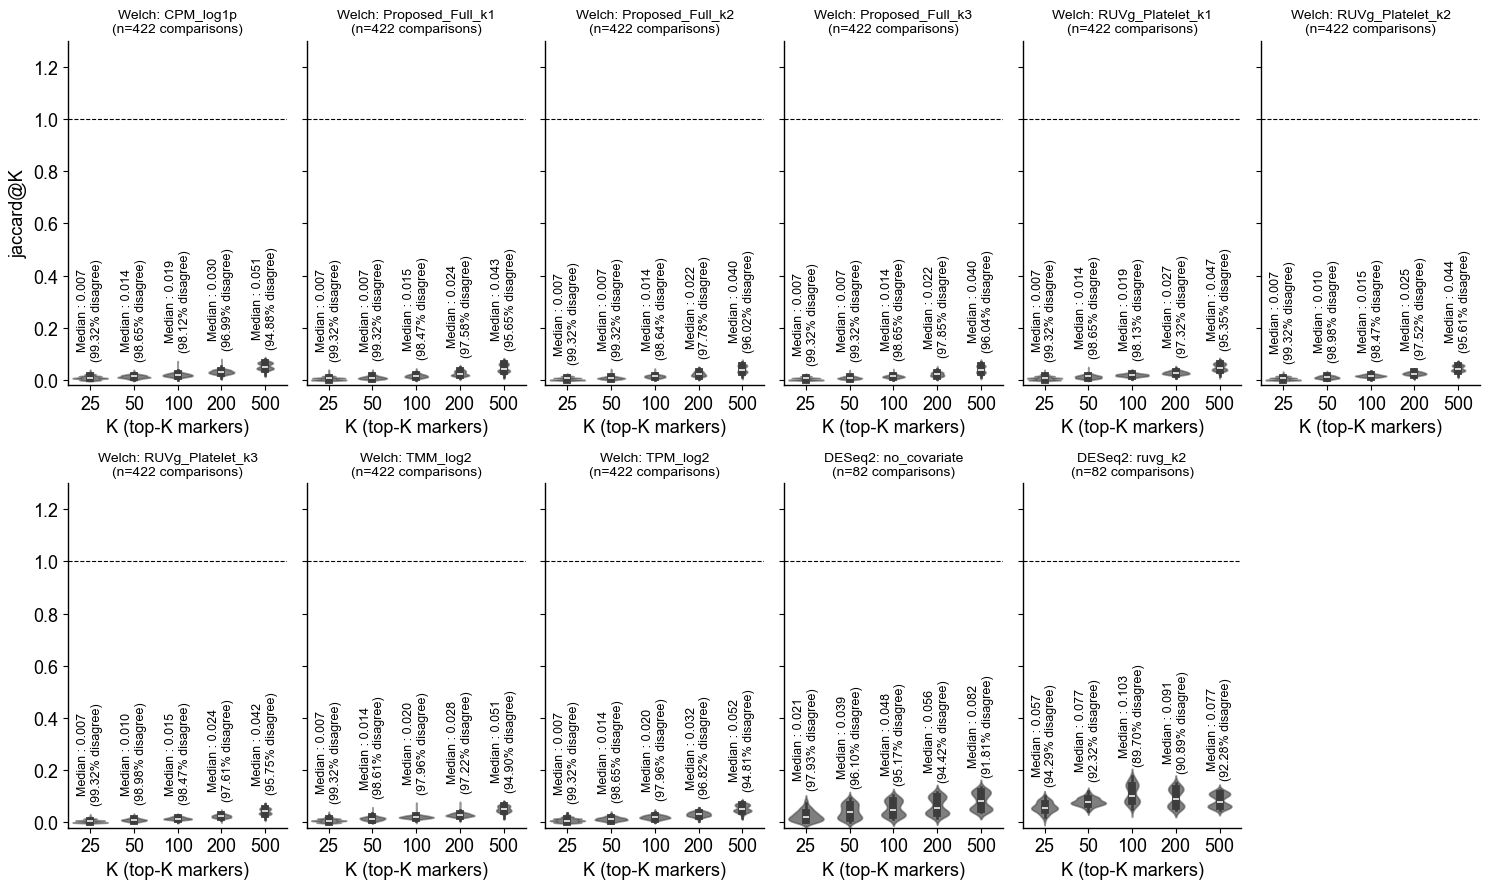

In [67]:
import seaborn as sns
K_SHOW = [25, 50, 100, 200, 500]

def plot_headline(ax, allc, title):
    data = [allc[f'jaccard_k{k}'].dropna().values for k in K_SHOW]
    sns.violinplot(
    ax=ax,
    data=data,
    color="black",
    inner="box",
    alpha=0.5,
    )
    for i, k in enumerate(K_SHOW):
        med, mx = np.median(data[i]), data[i].max()
        ax.text(i, mx + 0.05, f"Median : {med:.3f}\n({(1 - med) * 100:.2f}% disagree)", ha='center', fontsize=9, rotation=90)
    ax.axhline(1.0, color='black', ls='--', lw=0.8)
    ax.set_xticks(range(len(K_SHOW))); ax.set_xticklabels(K_SHOW)
    ax.set_xlabel('K (top-K markers)')
    ax.set_ylim(-0.02, 1.3)
    ax.set_title(f'{title}\n(n={allc["tag"].nunique()} comparisons)', fontsize=10)

allc_welch = pd.concat([res.assign(split='tertile'), null.assign(split='random')], ignore_index=True)
allc_deseq2 = pd.concat([d_res.assign(split='tertile'), d_null.assign(split='random')], ignore_index=True)

# every condition at once: 9 Welch-t layers + 2 DESeq2 designs, one panel each
conditions = [(allc_welch[allc_welch.layer == l], f'Welch: {l}') for l in sorted(allc_welch['layer'].unique())]
conditions += [(allc_deseq2[allc_deseq2.layer == d], f'DESeq2: {d}') for d in sorted(allc_deseq2['layer'].unique())]

n_cols = 6
n_rows = int(np.ceil(len(conditions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 4.5 * n_rows), sharey=True)
axes = axes.flatten()
for ax, (df, title) in zip(axes, conditions):
    plot_headline(ax, df, title)
for ax in axes[len(conditions):]:
    ax.axis('off')
axes[0].set_ylabel('jaccard@K')
plt.tight_layout()
plt.savefig(config.CTRL_COMP_FIG_DIR / 'headline_jaccard_floor_all_conditions.png', dpi=150)
plt.show()